<a href="https://colab.research.google.com/github/cse2023210012-prog/Student-Social-Media-And-Mental-Health-Impact-training-/blob/main/Student_Social_Media_And_Mental_Health_Impact.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gradio -q

import gradio as gr
import numpy as np
import pandas as pd

# 1. Define Prediction Function using X.columns (exact training features)
def predict_mental_health(age, usage_hours, unlocks, study_hours, sleep_hours, physical_hours):
    try:
        # Create a dataframe with 0s for all model features
        input_df = pd.DataFrame(0, index=[0], columns=X.columns)

        # Fill in the numerical values provided by sliders
        if 'Age' in input_df.columns: input_df['Age'] = age
        if 'Avg_Daily_Usage_Hours' in input_df.columns: input_df['Avg_Daily_Usage_Hours'] = usage_hours
        if 'Daily_Unlocks' in input_df.columns: input_df['Daily_Unlocks'] = unlocks
        if 'Study_Hours' in input_df.columns: input_df['Study_Hours'] = study_hours
        if 'Sleep_Hours_Per_Night' in input_df.columns: input_df['Sleep_Hours_Per_Night'] = sleep_hours
        if 'Physical_Activity_Hours' in input_df.columns: input_df['Physical_Activity_Hours'] = physical_hours

        # Make prediction using your tuned Random Forest model
        pred = best_rf.predict(input_df)[0]

        # Decode target label back to text if encoded
        if hasattr(le, 'inverse_transform'):
            result = le.inverse_transform([pred])[0]
        else:
            result = pred

        return f"Predicted Risk Level: {result}"

    except Exception as e:
        return f"Error details: {str(e)}"

# 2. Build Interface
demo = gr.Interface(
    fn=predict_mental_health,
    inputs=[
        gr.Slider(15, 30, value=20, step=1, label="Age"),
        gr.Slider(0.0, 12.0, value=4.5, step=0.5, label="Daily Social Media (Hours)"),
        gr.Slider(10, 300, value=120, step=5, label="Daily Phone Unlocks"),
        gr.Slider(0.0, 12.0, value=4.0, step=0.5, label="Study Hours"),
        gr.Slider(2.0, 12.0, value=7.0, step=0.5, label="Sleep Hours"),
        gr.Slider(0.0, 5.0, value=1.5, step=0.5, label="Physical Activity (Hours)"),
    ],
    outputs=gr.Textbox(label="Prediction Result"),
    title="🧠 Student Mental Health Risk Predictor",
)

# 3. Launch UI
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5a254ee5479e5bc000.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [24]:
# IMPORTS LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import warnings

warnings.filterwarnings("ignore")

In [25]:
#df = pd.read_csv('Student Social Media And Mental Health Impact.csv')
url = 'https://raw.githubusercontent.com/cse2023210012-prog/Student-Social-Media-And-Mental-Health-Impact-training-/main/Student%20Social%20Media%20And%20Mental%20Health%20Impact.csv'

df = pd.read_csv(url)

In [3]:
df

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


In [10]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [4]:
# Detect missing values
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [26]:
# Count total duplicate rows
df.duplicated().sum()

np.int64(2)

In [27]:
# Drop duplicate rows (keeps first by default)
df = df.drop_duplicates()

In [28]:
# Remove outliers using Z-Score
from scipy import stats

# Select specific columns
cols = ["Age", "Avg_Daily_Usage_Hours",   "Sleep_Hours_Per_Night"]

# Calculate Z-scores, check if absolute value < 3, and ensure ALL selected columns satisfy the condition
df_clean = df[
    (np.abs(stats.zscore(df[cols], nan_policy="omit")) < 3).all(axis=1)
]

**Some of Orginal Dataset before tranform to Categories(Feauture engineering)**

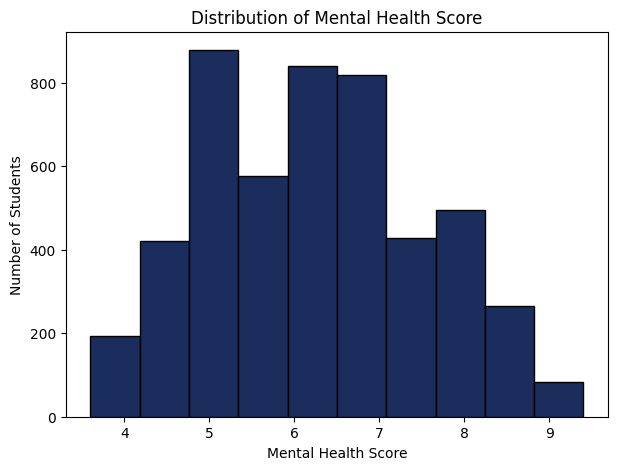

In [52]:
plt.figure(figsize=(7,5))
plt.hist(df["Mental_Health_Score"], bins=10, edgecolor='black',color='#1a2d5c')
plt.title("Distribution of Mental Health Score")
plt.xlabel("Mental Health Score")
plt.ylabel("Number of Students")
plt.show()

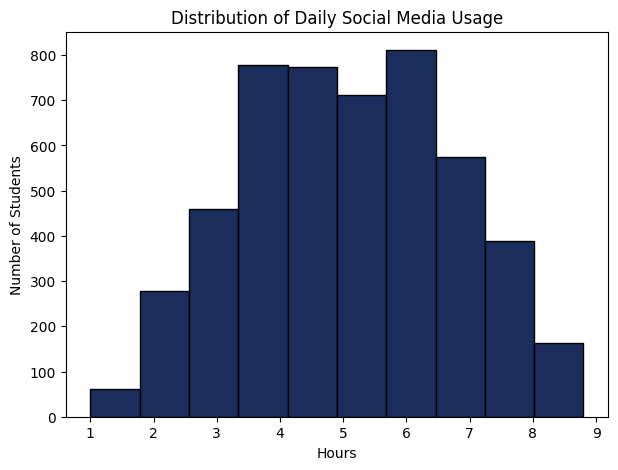

In [51]:
plt.figure(figsize=(7,5))
plt.hist(df["Avg_Daily_Usage_Hours"], bins=10, edgecolor='black',color="#1a2d5c")
plt.title("Distribution of Daily Social Media Usage")
plt.xlabel("Hours")
plt.ylabel("Number of Students")
plt.show()

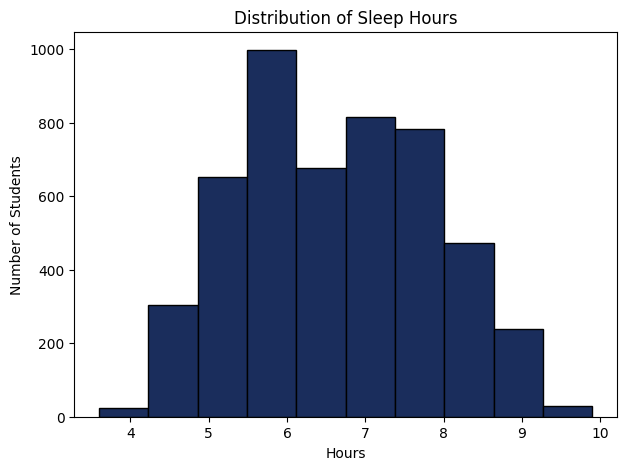

In [53]:
plt.figure(figsize=(7,5))
plt.hist(df["Sleep_Hours_Per_Night"], bins=10, edgecolor='black',color='#1a2d5c')
plt.title("Distribution of Sleep Hours")
plt.xlabel("Hours")
plt.ylabel("Number of Students")
plt.show()

In [73]:
# PREPROCESSING & FEATURE ENGINEERING
# Bin Mental_Health_Score into 3 risk categories
bins = [0, 4, 7, 10]
labels = ['Poor', 'Fair', 'Good']
df['Mental_Health_Category'] = pd.cut(df['Mental_Health_Score'], bins=bins, labels=labels)
df = df.dropna(subset=['Mental_Health_Category'])

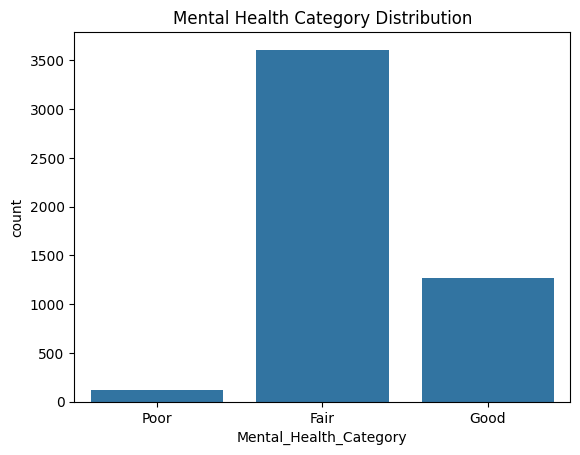

In [57]:
sns.countplot(
    data=df,
    x='Mental_Health_Category',
    order=['Poor','Fair','Good']
)
plt.title('Mental Health Category Distribution')
plt.show()

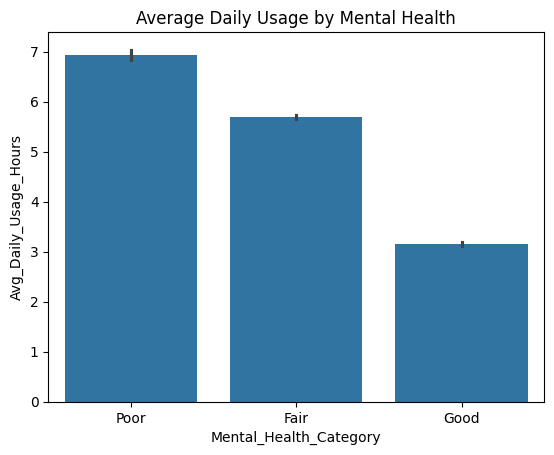

In [58]:
sns.barplot(
    data=df,
    x='Mental_Health_Category',
    y='Avg_Daily_Usage_Hours'
)
plt.title('Average Daily Usage by Mental Health')
plt.show()

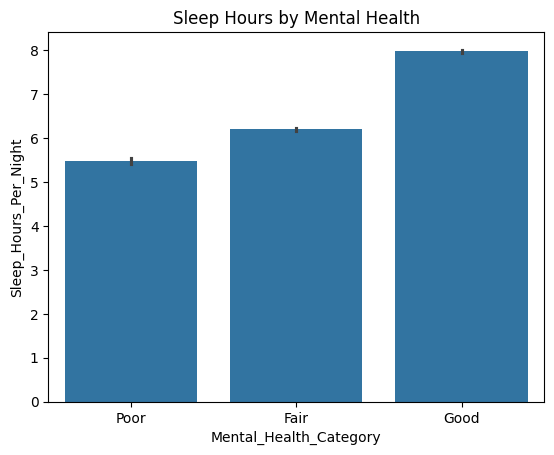

In [59]:
sns.barplot(
    data=df,
    x='Mental_Health_Category',
    y='Sleep_Hours_Per_Night'
)
plt.title('Sleep Hours by Mental Health')
plt.show()

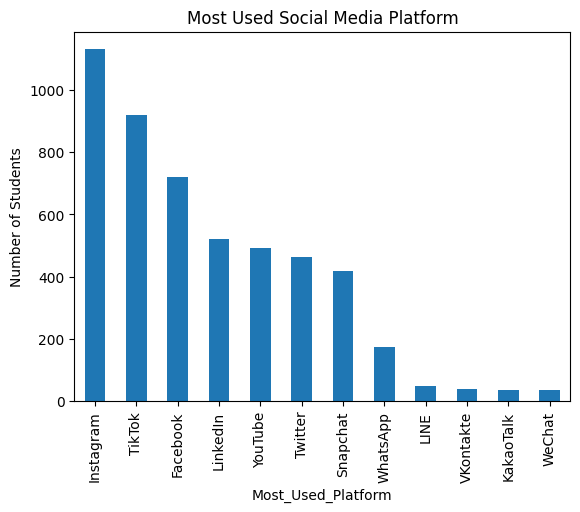

In [62]:
df['Most_Used_Platform'].value_counts().plot(kind='bar')
plt.title('Most Used Social Media Platform')
plt.ylabel('Number of Students')
plt.show()

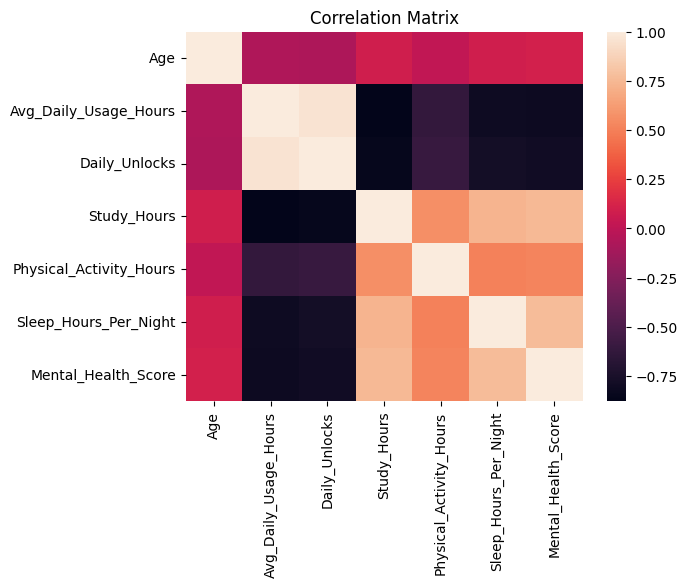

In [64]:
sns.heatmap(df.corr(numeric_only=True))
plt.title('Correlation Matrix')
plt.show()

In [76]:
# Encode target categories into numbers (0, 1, 2)
le = LabelEncoder()
y = le.fit_transform(df['Mental_Health_Category'])

# Separate features (X) and drop targets to prevent data leakage
X_raw = df.drop(columns=['Mental_Health_Score', 'Mental_Health_Category', 'Stress_Level'], errors='ignore')

# One-Hot Encode categorical/text columns
X = pd.get_dummies(X_raw, drop_first=True)

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Training Logistic Regression...

Best Parameters:
{'lr__C': 0.1, 'lr__solver': 'newton-cg'}

Classification Report (Logistic Regression)

              precision    recall  f1-score   support

        Fair       0.93      0.96      0.94       722
        Good       0.89      0.87      0.88       255
        Poor       0.50      0.17      0.26        23

    accuracy                           0.92      1000
   macro avg       0.77      0.67      0.69      1000
weighted avg       0.91      0.92      0.91      1000



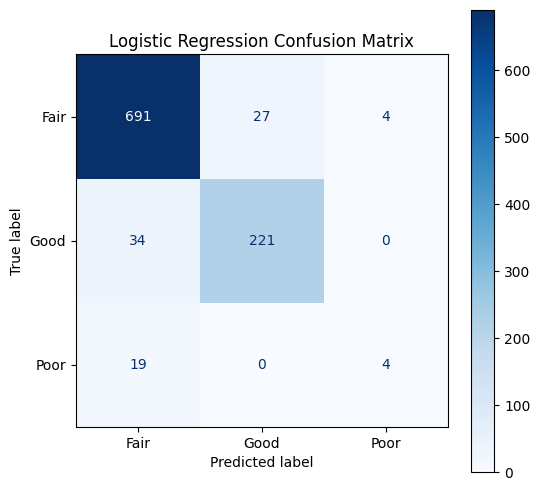

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# =========================================================
# LOGISTIC REGRESSION (BASELINE MODEL)
# =========================================================

# Create Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        random_state=42,
        max_iter=1000,
        multi_class='multinomial'
    ))
])

# Hyperparameters
param_grid = {
    'lr__C': [0.01, 0.1, 1, 10],
    'lr__solver': ['lbfgs', 'newton-cg']
}

# Grid Search
lr_grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

print("Training Logistic Regression...")
lr_grid.fit(X_train, y_train)

# Prediction
best_lr = lr_grid.best_estimator_

y_pred_lr = best_lr.predict(X_test)

#Evaulation
print("\nBest Parameters:")
print(lr_grid.best_params_)

print("\nClassification Report (Logistic Regression)\n")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=le.classes_
))

# VISUALIZATION (CONFUSION MATRIX)
fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay.from_estimator(
    best_lr,
    X_test,
    y_test,
    display_labels=le.classes_,
    cmap='Blues',
    ax=ax
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

Training Random Forest Classifier...

Best Parameters Found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Classification Report (Random Forest):

              precision    recall  f1-score   support

        Fair       0.94      0.95      0.95       722
        Good       0.89      0.87      0.88       255
        Poor       0.67      0.43      0.53        23

    accuracy                           0.92      1000
   macro avg       0.83      0.75      0.78      1000
weighted avg       0.92      0.92      0.92      1000



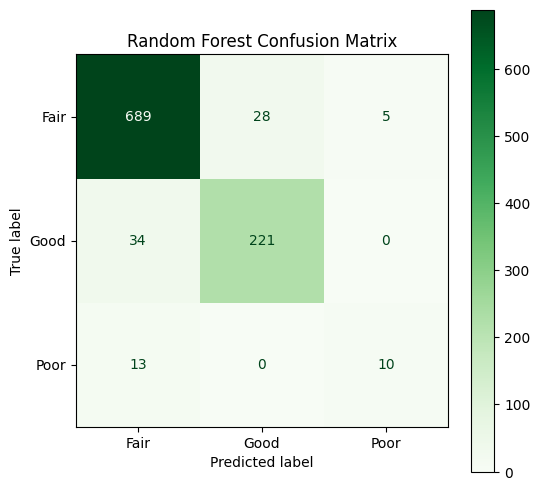

In [75]:
# =========================================================
# Student A : RANDOM FOREST CLASSIFIER
# =========================================================

# HYPERPARAMETER TUNING WITH GRIDSEARCHCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

print("Training Random Forest Classifier...")
rf_grid.fit(X_train, y_train)

# EVALUATION
best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("\nBest Parameters Found:", rf_grid.best_params_)
print("\nClassification Report (Random Forest):\n")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# VISUALIZATION (CONFUSION MATRIX)
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, display_labels=le.classes_, ax=ax, cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.show()

Training XGBoost Classifier...

Best Parameters Found: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}

Classification Report (XGBoost):

              precision    recall  f1-score   support

        Fair       0.94      0.96      0.95       722
        Good       0.91      0.87      0.89       255
        Poor       0.58      0.48      0.52        23

    accuracy                           0.93      1000
   macro avg       0.81      0.77      0.79      1000
weighted avg       0.92      0.93      0.92      1000



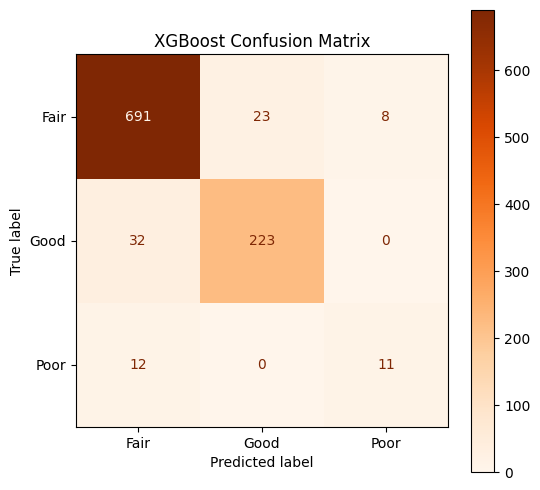

In [78]:
# =========================================================
# STUDENT B: XGBOOST CLASSIFIER
# =========================================================

# 1. INSTALL & IMPORTS
!pip install xgboost -q

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# 4. HYPERPARAMETER TUNING WITH GRIDSEARCHCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

print("Training XGBoost Classifier...")
xgb_grid.fit(X_train, y_train)

# 5. EVALUATION
best_xgb = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("\nBest Parameters Found:", xgb_grid.best_params_)
print("\nClassification Report (XGBoost):\n")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

# 6. VISUALIZATION (CONFUSION MATRIX)
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test, display_labels=le.classes_, ax=ax, cmap='Oranges')
plt.title('XGBoost Confusion Matrix')
plt.show()


In [79]:
print(X.columns.tolist())

['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night', 'Gender_Male', 'Country_Albania', 'Country_Andorra', 'Country_Argentina', 'Country_Armenia', 'Country_Australia', 'Country_Austria', 'Country_Azerbaijan', 'Country_Bahamas', 'Country_Bahrain', 'Country_Bangladesh', 'Country_Belarus', 'Country_Belgium', 'Country_Bhutan', 'Country_Bolivia', 'Country_Bosnia', 'Country_Brazil', 'Country_Bulgaria', 'Country_Canada', 'Country_Chile', 'Country_China', 'Country_Colombia', 'Country_Costa Rica', 'Country_Croatia', 'Country_Cyprus', 'Country_Czech Republic', 'Country_Denmark', 'Country_Ecuador', 'Country_Egypt', 'Country_Estonia', 'Country_Finland', 'Country_France', 'Country_Georgia', 'Country_Germany', 'Country_Ghana', 'Country_Greece', 'Country_Hong Kong', 'Country_Hungary', 'Country_Iceland', 'Country_India', 'Country_Indonesia', 'Country_Iraq', 'Country_Ireland', 'Country_Israel', 'Country_Italy', 'Country_Jamaica', 'Country_J

In [80]:
!pip install gradio -q

import gradio as gr
import pandas as pd
import numpy as np

# ----------------------------
# Dropdown values
# ----------------------------

countries = [
'Other','Albania','Andorra','Argentina','Armenia','Australia','Austria',
'Azerbaijan','Bahamas','Bahrain','Bangladesh','Belarus','Belgium',
'Bhutan','Bolivia','Bosnia','Brazil','Bulgaria','Canada','Chile',
'China','Colombia','Costa Rica','Croatia','Cyprus','Czech Republic',
'Denmark','Ecuador','Egypt','Estonia','Finland','France','Georgia',
'Germany','Ghana','Greece','Hong Kong','Hungary','Iceland','India',
'Indonesia','Iraq','Ireland','Israel','Italy','Jamaica','Japan',
'Jordan','Kazakhstan','Kenya','Kosovo','Kuwait','Kyrgyzstan',
'Latvia','Lebanon','Liechtenstein','Lithuania','Luxembourg',
'Malaysia','Maldives','Malta','Mexico','Moldova','Monaco',
'Montenegro','Morocco','Nepal','Netherlands','New Zealand',
'Nigeria','North Macedonia','Norway','Oman','Pakistan',
'Panama','Paraguay','Peru','Philippines','Poland','Portugal',
'Qatar','Romania','Russia','San Marino','Serbia','Singapore',
'Slovakia','Slovenia','South Africa','South Korea','Spain',
'Sri Lanka','Sweden','Switzerland','Syria','Taiwan',
'Tajikistan','Thailand','Trinidad','Turkey','UAE','UK',
'USA','Ukraine','Uruguay','Uzbekistan','Vatican City',
'Venezuela','Vietnam','Yemen'
]

platforms = [
'Facebook',
'Instagram',
'KakaoTalk',
'LINE',
'LinkedIn',
'Snapchat',
'TikTok',
'Twitter',
'VKontakte',
'WeChat',
'WhatsApp',
'YouTube'
]

academic = [
'Graduate',
'High School',
'Undergraduate'
]

purpose = [
'Education',
'Entertainment',
'Networking',
'News'
]

# ----------------------------
# Prediction Function
# ----------------------------

def predict(model_name,
            age,
            usage,
            unlocks,
            study,
            physical,
            sleep,
            gender,
            country,
            academic_level,
            platform,
            purpose_use):

    # Create empty dataframe
    sample = pd.DataFrame(0, index=[0], columns=X.columns)

    # Numerical Features
    sample["Age"] = age
    sample["Avg_Daily_Usage_Hours"] = usage
    sample["Daily_Unlocks"] = unlocks
    sample["Study_Hours"] = study
    sample["Physical_Activity_Hours"] = physical
    sample["Sleep_Hours_Per_Night"] = sleep

    # Gender
    sample["Gender_Male"] = 1 if gender == "Male" else 0

    # Country
    col = f"Country_{country}"
    if col in sample.columns:
        sample[col] = 1

    # Academic
    col = f"Academic_Level_{academic_level}"
    if col in sample.columns:
        sample[col] = 1

    # Platform
    col = f"Most_Used_Platform_{platform}"
    if col in sample.columns:
        sample[col] = 1

    # Purpose
    col = f"Purpose_Of_Use_{purpose_use}"
    if col in sample.columns:
        sample[col] = 1

    # Select Model
    if model_name == "Random Forest":
        model = best_rf
    elif model_name == "XGBoost":
        model = best_xgb
    else:
        model = best_lr

    pred = model.predict(sample)[0]

    label = le.inverse_transform([pred])[0]

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(sample)[0]
        confidence = np.max(probs) * 100

        return (
            f"### Prediction\n\n"
            f"**Mental Health Category:** {label}\n\n"
            f"**Confidence:** {confidence:.2f}%"
        )

    return f"### Prediction\n\n**Mental Health Category:** {label}"

# ----------------------------
# Interface
# ----------------------------

demo = gr.Interface(

    fn=predict,

    inputs=[

        gr.Dropdown(
            ["Logistic Regression","Random Forest","XGBoost"],
            value="Random Forest",
            label="Select Model"
        ),

        gr.Slider(15,30,20,1,label="Age"),

        gr.Slider(0,12,4.5,0.5,label="Daily Usage (Hours)"),

        gr.Slider(10,300,120,5,label="Daily Unlocks"),

        gr.Slider(0,12,4,0.5,label="Study Hours"),

        gr.Slider(0,5,1.5,0.5,label="Physical Activity"),

        gr.Slider(2,12,7,0.5,label="Sleep Hours"),

        gr.Radio(["Male","Female"],value="Male",label="Gender"),

        gr.Dropdown(countries,value="Other",label="Country"),

        gr.Dropdown(academic,value="Undergraduate",label="Academic Level"),

        gr.Dropdown(platforms,value="Instagram",label="Most Used Platform"),

        gr.Dropdown(purpose,value="Entertainment",label="Purpose of Use")

    ],

    outputs=gr.Markdown(),

    title="🧠 Student Mental Health Prediction System",

    description="""
Predict a student's mental health category using Machine Learning models.
Choose Logistic Regression, Random Forest, or XGBoost and enter the student's information.
"""
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0bcc7cc3ee2f7807b3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
